## Embedding exploration

the purpose of this notebook is to explore where different samples of the model states/obs end up once embedded into diffusion space.

In [1]:
import numpy as np 
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.io import loadmat
from scipy.sparse.linalg import eigsh

reload(dap)

np.set_printoptions(suppress=True)


In [2]:
uoep = {'mu': 0, 'sigma': 1}
poep = {'mu': 0, 'sigma': 1} 
fice_uoep = {'mu': 0, 'sigma': 0.1, 'lnmu': 0, 'lnsigma': 1, 'lnscale': 30 } 
fice_t_params = {
    'a': 2, 'shift': 0.0, 'h_noise':0.0, 'v_noise':0.0, 'Nx':120, 'bound':3}
fice_e_params = {
    'a': 10, 'shift': 0.0,'h_noise':0.4, 'v_noise':0.0, 'Nx':120, 'bound': 3}
lfice_t_params = {
    'v_noise':0.01, 'Nx':120, 'f':1/2}
lfice_e_params = {
    'v_noise':0.0, 'Nx':120, 'f':1/2}
pfice_t_params = {
          'a1':10, 'a2':3, 'roll':0, 'v_noise':0.01, 'Nx':100}
pfice_e_params = {
          'a1':10, 'a2':3, 'roll':0, 'v_noise':0.0, 'Nx':100}
stagger_params = {
          'v_noise':0.01, 'Nx':120}


#fice_poep = {'mu': 0, 'sigma': 0.3, 'lnmu': 0, 'lnsigma': 1, 'lnscale': 30 }  
#poep = {'mu': 0}

starting experiment Toy Ice Model
DB: starting cycle 0
DB: starting cycle 200


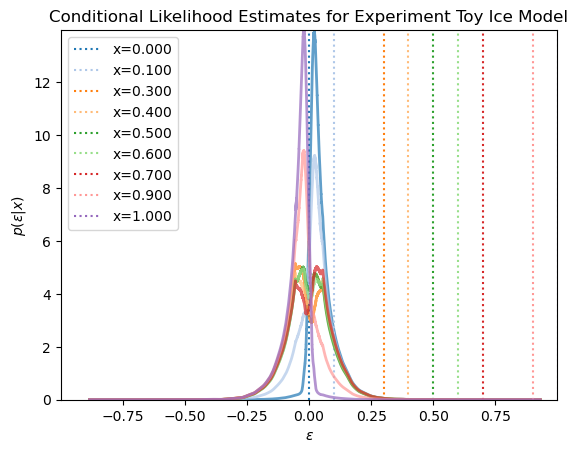

<Figure size 640x480 with 0 Axes>

In [3]:
#bad: 0.2 0.2
#good, 0.1 0.01
for knn in [0.2]:
    for bw in [0.05]:
        for klb in [0]:
            e_name = f'Toy Ice Model'
            print(f'starting experiment {e_name}')
            e = dap.Expt(e_name, {'expt_flag': 3,
                                   'model_flag':4,
                                   'localize':0,
                                   'obf': 1,
                                   'seed': 58,
                                   'qc_flag': 0,
                                   'used_obs_err': 2,
                                   'prescribed_obs_err': 0,
                                   'used_obs_err_params': fice_uoep,
                                   'prescribed_obs_err_params': poep,
                                   'fice_t_params': fice_t_params,
                                   'fice_e_params': fice_e_params,
                                   'lfice_t_params': lfice_t_params,
                                   'lfice_e_params': lfice_e_params,
                                   'pfice_t_params': pfice_t_params,
                                   'pfice_e_params': pfice_e_params,
                                   'stagger_params':stagger_params,
                                   'save_keest_pab':1,
                                   'saveEns': True,
                                   'Ne':3,
                                   'nle_every': 200,
                                   'nle_type': 2,
                                   'Nb': 0,
                                   'T': 301,
                                   'T_train': 300,
                                   'Neig': 15,
                                   'knn_frac': knn,
                                   'bw_dm': bw,
                                   'klb':klb,
                                   'debug_nle_noDA': True})
            dap.runDA(e)
    #dap.saveExpt('.', e) 
            fig, ax = plt.subplots()
            dap.plot_pab(e, ax=ax, plot_states=True, pab_sample_states=[0,0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1])
#   fig.savefig(f'{e_name}.png')
#   plt.close()
#   dest = f't{i}.mat'
#   !mkdir ../experiments/temp
#   #!mv {e_name}.expt ../experiments/$e_name
#   #!mv {e_name}.png ../experiments/$e_name
#   !mv training.mat ../experiments/$dest

In [66]:
x_train, x_map = e.x_train, e.x_map
y_train, y_map = e.y_train, e.y_map
evec_x, eval_x, a_train_x, bwx = x_map
evec_y, eval_y, a_train_y, bwy = y_map

x_emb = (evec_x * eval_x).T
y_emb = (evec_y * eval_y).T

Nx = e.getParam('Nx')
Nb = e.getParam('Nb')
x_dom = np.linspace(-fice_t_params['bound'], fice_t_params['bound'], fice_t_params['Nx']) 
model_flag = e.getParam('model_flag')

ts = np.linspace(0, 2*np.pi, Nx)
xs, ys = np.cos(ts), np.sin(ts)

plot_x=True
plot_3d=False
plot_oma=True
ind=30
for ind in range(2*Nb,Nx-2*Nb):
    ind = -ind    
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(1,2,1)
    if plot_3d:
        ax2 = fig.add_subplot(1,2,2, projection='3d')
    else:
        ax2 = fig.add_subplot(1,2,2)
    if plot_x:
        im = ax1.scatter(x_emb[1], x_emb[2], s=10)
    else:
        im = ax1.scatter(y_emb[1], y_emb[2], s=10)
    Nb=e.getParam('Nb')
    if plot_x:
        ax1.scatter(x_emb[1,ind], x_emb[2,ind], c='red', s=50)
    else:
        ax1.scatter(y_emb[1,ind], y_emb[2,ind], c='red', s=50)
    if plot_x:
        dap.plotExpt(e, 99, ax2, plotEns=False, plotObs=False)
    else:
        dap.plotExpt(e, 99, ax2, plotEns=False, plotObs=True)
    if plot_3d:
        if plot_x:
            if Nb == 0:
                ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], x_train[:,ind], c='red', zorder=10)
            else:
                ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], x_train[:,ind], c='red', zorder=10)
        else:
            if Nb == 0:
                if plot_oma:
                    ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind] + x_train[:,ind], c='red', zorder=10)
                else:
                    ax2.scatter(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind] , c='red', zorder=10)
            else:
                if plot_oma:
                    ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind]+x_train[:,ind], c='red', zorder=10)
                else:
                    ax2.plot(xs[ind-Nb:ind+Nb+1],ys[ind-Nb:ind+1+Nb], y_train[:,ind], c='red', zorder=10)
    else:
        if model_flag == 4:
            plotx= x_dom
        else:
            plotx = np.arange(0,Nx,1)
        if plot_x:
            ax2.scatter(plotx[ind],x_train[:,ind], c='red', zorder=10, s=50)
        else:
            if plot_oma:
                ax2.scatter(plotx[ind],y_train[:,ind] +x_train[:,ind], c='red', zorder=10, s=50)
                ax2.vlines(plotx[ind], x_train[:,ind], y_train[:,ind] + x_train[:,ind], color='red', lw=5, zorder=10)
            else:
                ax2.scatter(plotx[ind],y_train[:,ind], c='red', zorder=10, s=50)
    ax1.set_xlabel('$\\phi_1$')
    ax1.set_ylabel('$\\phi_2$')
    ax1.set_title('Diffusion Map Embedding of $x$ - \"Discrete\" Ice Model')
    ax2.set_ylabel('Model State')
    ax2.set_xticks([])
    ax2.set_title('Original State $x$')
    

    fig.savefig(f'gif_figs/stagger/x_emb/stagger_embedding_x{-ind:03d}.png')
    plt.close()


In [26]:
xf_0, xt, Y = e.getStates()
xt.shape

(120, 101)

In [16]:
x_train[:,ind]

array([1.])

In [40]:
state = np.concatenate([np.ones(24) * i/4 for i in range(5)])[::-1]
xt

array([[ 0.99813258,  0.99615514,  0.99516232, ...,  0.99472609,
         0.99389616,  1.00496279],
       [ 1.01328281,  0.9905407 ,  0.98147754, ...,  1.00393003,
         1.00570011,  0.99468695],
       [ 1.01116154,  0.98562032,  0.99443378, ...,  1.01167505,
         1.01921508,  0.98444654],
       ...,
       [ 0.00937855,  0.01927367,  0.01429034, ..., -0.00241621,
        -0.00161175, -0.01344118],
       [ 0.0027132 , -0.01828345, -0.01354479, ..., -0.00611542,
        -0.000644  ,  0.00115818],
       [ 0.01337978, -0.00153904, -0.01376299, ..., -0.00025954,
         0.01892156, -0.00096114]])

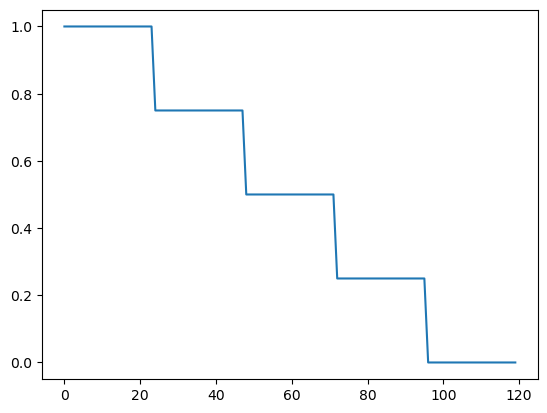

In [41]:
plt.plot(state)